In [ ]:
%%capture
#imports
!pip install pyarrow scikit-learn matplotlib seaborn umap-learn scipy statsmodels requests rapidfuzz tqdm

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif

import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests
from bs4 import BeautifulSoup
import time
from tqdm import tqdm
import csv
from rapidfuzz import fuzz
import json

from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.manifold import TSNE

import umap
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from matplotlib.patches import Ellipse
from matplotlib.patches import Patch

sns.set_style("whitegrid")
sns.set_context("talk")

In [ ]:
#the original parquet containing all the metabolites
df = pd.read_parquet("/content/wide_metabolites.parquet")
df.head()

,depression_status,file_name,"((1R,2R,5R)-2-(2,6-Dimethoxy-4-(2-methyloctan-2-yl)phenyl)-7,7-dimethyl-4-bicyclo(3.1.1)hept-3-enyl) methanol","((2,6-Bis(1-methylethyl)phenoxy)sulfonyl)carbamic acid 2,6-bis(1-methylethyl)phenyl ester",((2-Amino-3-((2-amino-3-((carboxymethyl)amino)-3-oxopropyl)dithio)propanoyl)amino)acetic acid,"((2R,3S)-3-Amino-2-hydroxy-2-(1H-imidazol-4-ylmethyl)-5-methyl)-5-methylhexanoic Acid","((2R,3S,4S,5R,6S)-6-(2-(3-(Benzofuran-5-yl)propanoyl)-3-hydroxy-5-methylphenoxy)-3,4,5-trihydroxytetrahydro-2H-pyran-2-yl)methyl methyl carbonate","((2R,5R)-2-Benzyl-5-(prop-2-yn-1-yloxy)piperidin-1-yl)(4-(bis(4-fluorophenyl)(hydroxy)methyl)-2H-1,2,3-triazol-2-yl)methanone","((4-(3-(4-Fluoro-alpha-hydroxybenzyl)-4-hydroxyphenoxy)-3,5-dimethylphenyl)amino)oxoacetate",((4-(4-Amidinophenoxy)butanoyl)aspartyl)valine,...,"{3,5-Dichloro-4-[4-Hydroxy-3-(Propan-2-Yl)phenoxy]phenyl}acetic Acid","{4-[({2-[3-Fluoro-4-(Trifluoromethyl)phenyl]-4-Methyl-1,3-Thiazol-5-Yl}methyl)sulfanyl]-2-Methylphenoxy}acetic Acid",{4-[2-Acetylamino-2-(1-biphenyl-4-ylmethyl-2-oxo-azepan-3-ylcarbamoyl)-ethyl]-2-phosphono-phenoxy}-acetic acid,"{4-[4-(6-Carbamoyl-3,5-dimethylpyrazin-2-yl)phenyl]cyclohexyl}acetic acid","{[5-(5-Nitro-2-furyl)-1,3,4-oxadiazol-2-YL]thio}acetic acid",Α-chaconine,α-D-GlcNAc3S-(1→4)-β-D-GlcA(1→3)-β-D-Gal(1→3)-β-D-Gal(1→4)-D-Xyl,β-L-IdoA-(1→4)-α-D-GlcNAc3S-(1→4)-β-D-GlcA(1→3)-β-D-Gal(1→3)-β-D-Gal(1→4)-D-Xyl,β-L-IdoA2S-(1→4)-α-D-GlcNAc3S-(1→4)-β-D-GlcA(1→3)-β-D-Gal(1→3)-β-D-Gal(1→4)-D-Xyl,﻿Bosutinib
0,1,PHT_20_128_Cort_1000_top10.csv,2.090140e+04,94456.437500,24006.970703,2.539550e+04,0.0,7.747589e+06,0.000000,57966972.0,...,1.709097e+07,0.0,0.000000,1880.219971,7.269436e+04,1724.439941,0.0,0.0,1543.719971,170449.281250
1,4,PHT_20_129_Cort_1000_top10.csv,7.653516e+05,1985.589966,13872.980469,6.723522e+04,0.0,0.000000e+00,1539.339966,50792656.0,...,1.387298e+04,0.0,1520.869995,1628.630005,1.517768e+06,0.000000,0.0,0.0,0.000000,1588.030029
2,3,PHT_20_127_Cort_1900_top10.csv,4.900854e+04,26955.150391,43092.980469,8.996620e+03,0.0,1.125140e+07,1836.060059,58654140.0,...,5.322293e+07,0.0,1707.510010,38062.539062,2.491092e+07,0.000000,0.0,0.0,0.000000,168857.593750
3,0,PHT_20_090_Cort_1900_top10.csv,9.154094e+06,67767.812500,13533.570312,6.232470e+04,0.0,2.276378e+04,0.000000,32385108.0,...,1.353357e+04,0.0,0.000000,1575.859985,2.093046e+06,0.000000,0.0,0.0,0.000000,0.000000
4,1,PHT_20_101_Cort_1000_top10.csv,5.844667e+04,0.000000,8335.240234,5.998930e+07,0.0,0.000000e+00,0.000000,31706448.0,...,8.335240e+03,0.0,0.000000,20067.070312,2.243427e+04,0.000000,0.0,0.0,0.000000,1866.709961


In [ ]:
df['depression_status'].value_counts()

#0/1 - not depressed
#2/3/4 - depressed

,count
depression_status,
0,113
4,72
1,39
3,30
2,15


In [ ]:
#turns depression_status into list
severity = df["depression_status"].astype(int)

#1 = depressed, 0 = not-depressed
y = (severity >= 2).astype(int)

meta_cols = ["depression_status", "file_name"]
X = df.drop(columns=meta_cols)

In [ ]:
#sanity check for depression scores
print(y.value_counts())
print(pd.crosstab(severity, y))

depression_status
0    152
1    117
Name: count, dtype: int64
depression_status    0   1
depression_status         
0                  113   0
1                   39   0
2                    0  15
3                    0  30
4                    0  72


In [ ]:
# Pre-Processing for Analysis
X_num = X.apply(pd.to_numeric, errors="coerce")

# drop features with too many missing values (tune threshold)
missing_frac = X_num.isna().mean(axis=0)
X_num = X_num.loc[:, missing_frac < 0.3]

# drop near-constant features
vt = VarianceThreshold(threshold=1e-12)
X_vt = vt.fit_transform(X_num.fillna(0))
kept = X_num.columns[vt.get_support()]
X_num = X_num[kept]

# impute
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_num)

# log1p for positive intensities
X_log = np.log1p(np.clip(X_imp, a_min=0, a_max=None))

# z-score per feature
scaler = StandardScaler()
X_z = scaler.fit_transform(X_log)

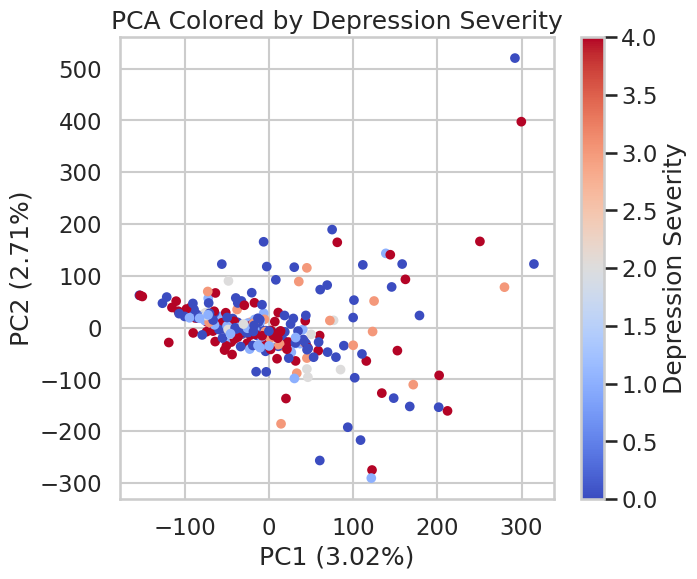

In [ ]:
#PCA by severity
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(X_z)

plt.figure(figsize=(7,6))
sc = plt.scatter(Z[:,0], Z[:,1], c=severity, cmap="coolwarm", s=30)

#plotting PCA
plt.colorbar(sc,label="Depression Severity")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA Colored by Depression Severity")
plt.show()

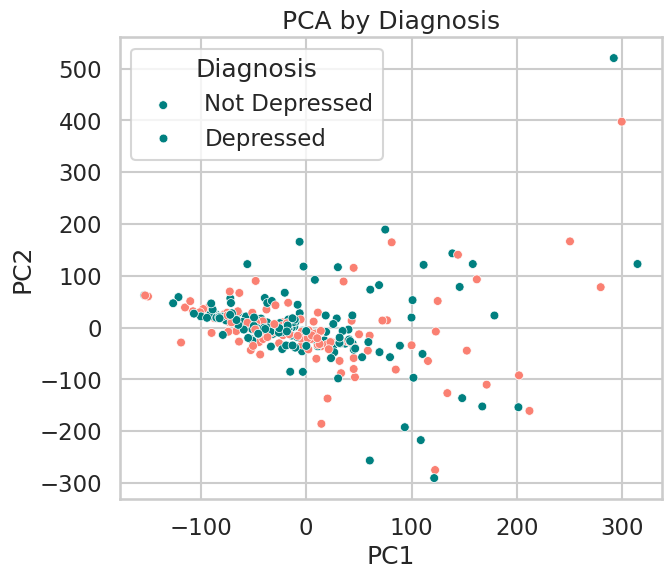

In [ ]:
#PCA by diagnosis (depressed vs not depressed)
plt.figure(figsize=(7,6))

#changes it from severity to binary
sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=y, palette=["teal","salmon"], s=40)

#plotting
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA by Diagnosis")
plt.legend(title="Diagnosis",labels=["Not Depressed","Depressed"])
plt.show()

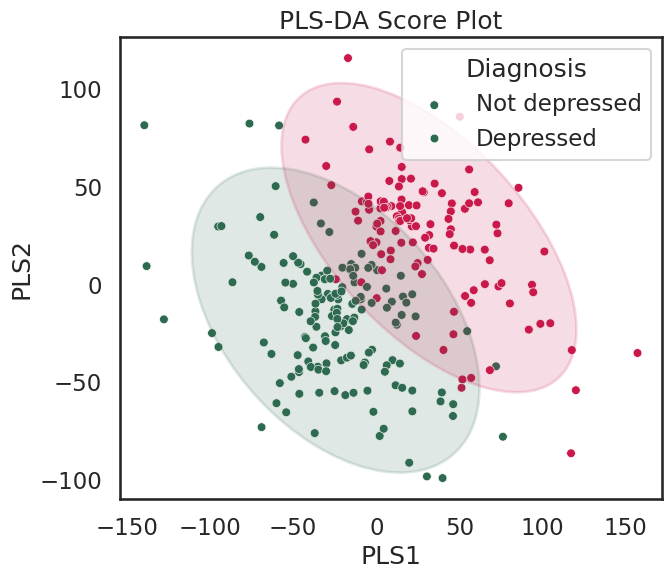

In [ ]:
#draw ellipse to verify distinction
def draw_ellipse(x, y, ax, color):
  cov = np.cov(x, y)
  mean = [np.mean(x), np.mean(y)]

  vals, vecs = np.linalg.eigh(cov)
  order = vals.argsort()[::-1]
  vals, vecs = vals[order], vecs[:, order]

  theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

  scale = np.sqrt(5.991)  # 95% CI for 2D
  width, height = 2 * scale * np.sqrt(vals)

  ell = Ellipse(mean, width, height, angle=theta, facecolor=color, alpha=0.15, edgecolor=color, linewidth=2)
  ax.add_patch(ell)

#pls analog
pls = PLSRegression(n_components=2)
y_np = np.asarray(y).astype(float).reshape(-1, 1)
pls.fit(X_z,y_np)

T = pls.x_scores_

#plot
fig, ax = plt.subplots(figsize=(7,6))
sns.scatterplot(x=T[:,0], y=T[:,1], hue=y, palette={0:"#2D6A4F", 1:"#C9184A"}, s=40, ax=ax)

for cls, color in zip([0,1], ["#2D6A4F", "#C9184A"]):
  idx = (y == cls)
  draw_ellipse(T[idx,0], T[idx,1], ax, color)

plt.xlabel("PLS1")
plt.ylabel("PLS2")
plt.title("PLS-DA Score Plot")
plt.legend(title="Diagnosis", labels=["Not depressed","Depressed"])
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


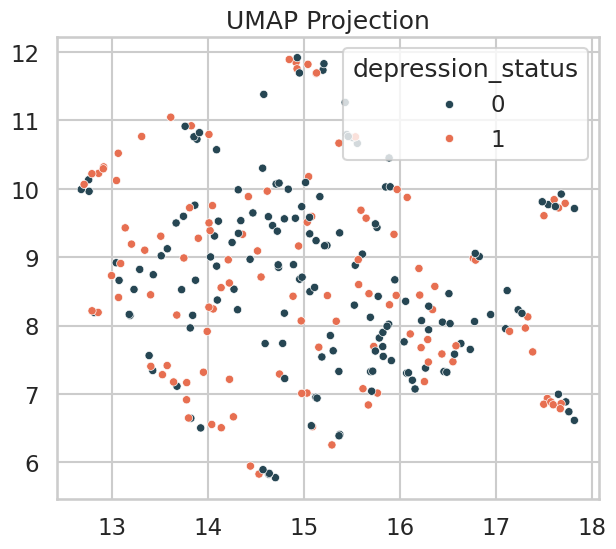

In [ ]:
#UMAP for depressed/not-depressed patients
U = umap.UMAP(n_neighbors=15,min_dist=0.1,random_state=0).fit_transform(X_z)

plt.figure(figsize=(7,6))
sns.scatterplot(x=U[:,0],y=U[:,1], hue=y, palette = {0:"#1D3557", 1:"#E63946"}, s=35)

plt.title("UMAP Projection")
plt.show()

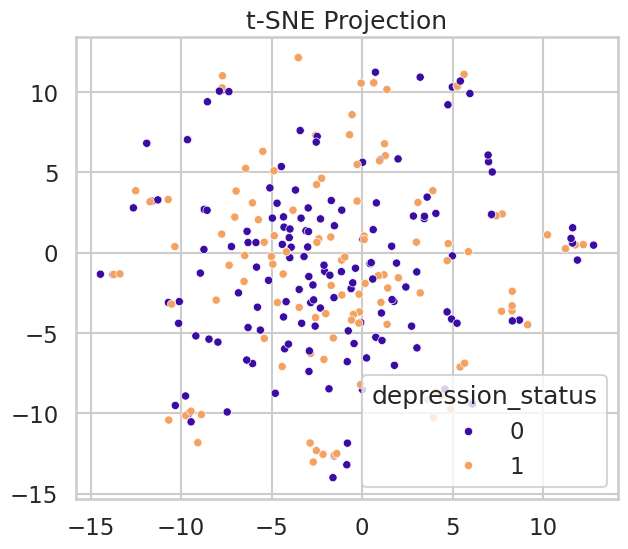

In [ ]:
#t-SNE for depressed/not-depressed patients
T = TSNE(n_components=2, perplexity=25, init="pca", learning_rate="auto", random_state=0).fit_transform(X_z)

plt.figure(figsize=(7,6))
sns.scatterplot(x=T[:,0], y=T[:,1], hue=y, palette={0:"#3A0CA3", 1:"#F4A261"}, s=35)

plt.title("t-SNE Projection")
plt.show()

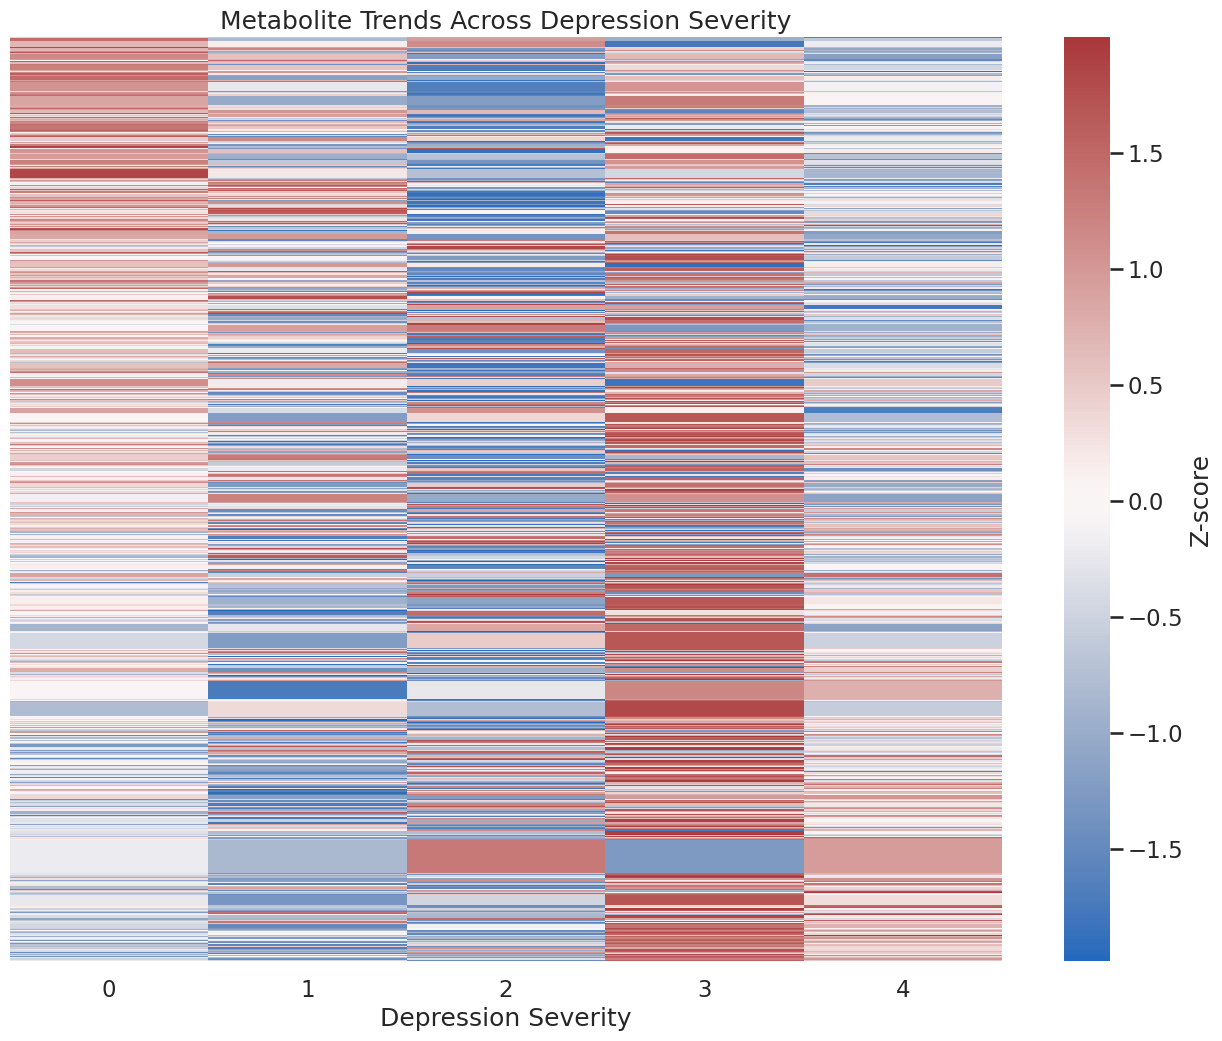

In [ ]:
severity = df["depression_status"].values  # 0–4

# Select many metabolites
TOP_N = 10000

# choose most variable metabolites (stable + informative)
var = X_log.var(axis=0)
idx = np.argsort(var)[-TOP_N:]

X_sel = X_log[:, idx]
feat_names = np.array(kept)[idx]

# mean per severity
means = []
for s in range(5):
  means.append(X_sel[severity == s].mean(axis=0))

M = np.array(means).T   # metabolites x severity levels

#Z-score across severity
M = (M - M.mean(axis=1, keepdims=True)) / (M.std(axis=1, keepdims=True)+1e-9)

df_plot = pd.DataFrame(M, index=feat_names, columns=[0,1,2,3,4])

corrs = np.array([
  spearmanr(X_sel[:,j], severity)[0]
  for j in range(X_sel.shape[1])
])

# sort metabolites by trend
order = np.argsort(corrs)
df_plot = df_plot.iloc[order]

# plot
plt.figure(figsize=(16,12))

sns.heatmap(df_plot, cmap="vlag", center=0, yticklabels=False, cbar_kws={"label":"Z-score"})

plt.xlabel("Depression Severity")
plt.title("Metabolite Trends Across Depression Severity")
plt.show()

Volcano Plot

In [ ]:
#Remove features with excessive missingness
missing_frac = X_num.isna().mean(axis=0)
X_num = X_num.loc[:, missing_frac < 0.3]

#Remove near-zero variance features
vt = VarianceThreshold(threshold=1e-12)
X_vt = vt.fit_transform(X_num.fillna(0))
kept = X_num.columns[vt.get_support()]
X_num = X_num[kept]

#Filter by feature presence frequency
presence = (X_num.fillna(0) > 0).mean(axis=0)
X_num = X_num.loc[:, presence >= 0.5]

#Keep top 5000 most variable metabolites
variances = X_num.fillna(0).var(axis=0)
keep_cols = variances.sort_values(ascending=False).head(5000).index
X_num = X_num[keep_cols]

#Impute remaining missing values
print("After filtering:", X_num.shape)
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_num)

#Log transformation for variance stabilizatio
X_log = np.log1p(np.clip(X_imp, a_min=0, a_max=None))
print("X_log:", X_log.shape)

After filtering: (269, 5000)
X_log: (269, 5000)


In [ ]:
# fold-change on linear intensities
X_lin = np.expm1(X_log)  # undo log1p
pos = X_lin[np.asarray(y) == 1]
neg = X_lin[np.asarray(y) == 0]

pos_med = np.median(pos, axis=0)
neg_med = np.median(neg, axis=0)

#remove unstable FC (medians near 0)
valid = (pos_med > 1) & (neg_med > 1)
log2fc = np.log2((pos_med[valid] + 1e-9) / (neg_med[valid] + 1e-9))

# MWU p-values on X_log
pvals = np.empty(X_log.shape[1], dtype=float)
for j in range(X_log.shape[1]):
  _, p = mannwhitneyu(
    X_log[np.asarray(y) == 1, j],
    X_log[np.asarray(y) == 0, j],
    alternative="two-sided"
  )
  pvals[j] = p

# apply same validity mask
pvals = pvals[valid]

# fdr
fdr = multipletests(pvals, method="fdr_bh")[1]

#assemble stats_df
features = X_num.columns[valid]

stats_df = pd.DataFrame({
  "feature": features,
  "log2FC": log2fc,
  "pval": pvals,
  "FDR": fdr,
  "neglog10p": -np.log10(np.clip(pvals, 1e-300, 1.0)),
  "neglog10FDR": -np.log10(np.clip(fdr, 1e-300, 1.0)),
}).sort_values("pval").reset_index(drop=True)

print("stats_df:", stats_df.shape)
stats_df.head()

stats_df: (4992, 6)


,feature,log2FC,pval,FDR,neglog10p,neglog10FDR
0,Cadalene,0.866969,0.003059,0.992391,2.514420,0.003317
1,"7-Isopropyl-1,4-dimethylazulene",0.866969,0.003059,0.992391,2.514420,0.003317
2,(±)-Sulfobutanedioic acid,0.520503,0.013993,0.992391,1.854098,0.003317
3,Hexyl 2-methyl-3-pentenoate,0.479467,0.022678,0.992391,1.644392,0.003317
4,cis-4-Decenyl acetate,0.479467,0.022678,0.992391,1.644392,0.003317


In [ ]:
#FDR analysis
print("min p:", stats_df["pval"].min())
print("min FDR:", stats_df["FDR"].min())
print("raw p<0.05:", (stats_df["pval"] < 0.05).sum())
print("FDR<0.1:", (stats_df["FDR"] < 0.1).sum())
print("Unique FDRs:", stats_df["FDR"].nunique())

min p: 0.0030590067804930616
min FDR: 0.9923911866048036
raw p<0.05: 105
FDR<0.1: 0
Unique FDRs: 11


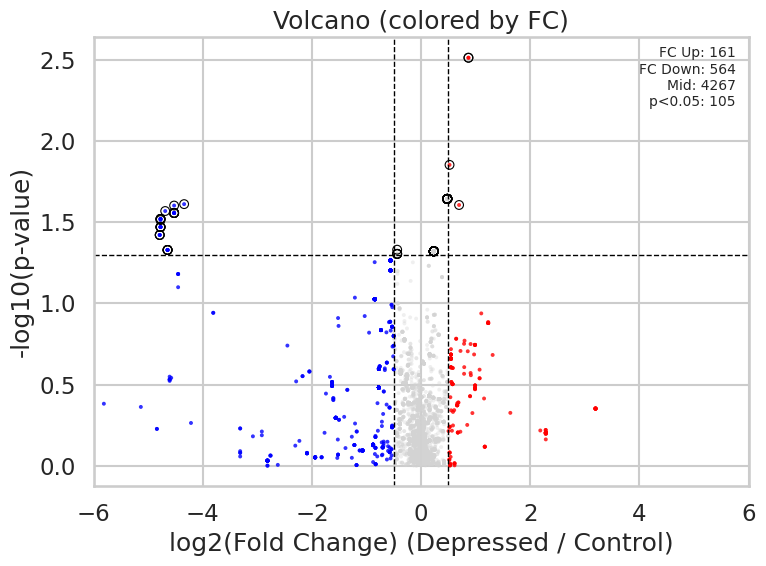

In [ ]:
def volcano_color_by_fc(df, fc_thresh=0.5, p_thresh=0.05, title="Volcano (colored by FC)"):
  df = df.copy()
  df["neglog10p"] = -np.log10(np.clip(df["pval"], 1e-300, 1.0))

  # color by fold-change only
  up_fc = df["log2FC"] >= fc_thresh
  down_fc = df["log2FC"] <= -fc_thresh
  mid = ~(up_fc | down_fc)

  # p-value significance (for optional overlay)
  p_sig = df["pval"] < p_thresh
  plt.figure(figsize=(8,6))

  # base layers
  plt.scatter(df.loc[mid, "log2FC"], df.loc[mid, "neglog10p"], s=8, alpha=0.35, c="lightgray", edgecolors="none")
  plt.scatter(df.loc[down_fc, "log2FC"], df.loc[down_fc, "neglog10p"], s=8, alpha=0.8, c="blue", edgecolors="none")
  plt.scatter(df.loc[up_fc, "log2FC"], df.loc[up_fc, "neglog10p"], s=8, alpha=0.8, c="red", edgecolors="none")

  # overlay: circle-outline points that also pass p-value threshold
  plt.scatter(df.loc[p_sig, "log2FC"], df.loc[p_sig, "neglog10p"], s=40, facecolors="none", edgecolors="black", linewidths=0.8)

  # threshold lines
  plt.axhline(-np.log10(p_thresh), linestyle="--", linewidth=1, color="black")
  plt.axvline(fc_thresh, linestyle="--", linewidth=1, color="black")
  plt.axvline(-fc_thresh, linestyle="--", linewidth=1, color="black")

  plt.xlabel("log2(Fold Change) (Depressed / Control)")
  plt.ylabel("-log10(p-value)")
  plt.xlim(-6, 6)
  plt.title(title)

  plt.text(0.98, 0.98, f"FC Up: {int(up_fc.sum())}\nFC Down: {int(down_fc.sum())}\nMid: {int(mid.sum())}\np<0.05: {int(p_sig.sum())}", ha="right", va="top", transform=plt.gca().transAxes, fontsize=10)

  plt.tight_layout()
  plt.show()

volcano_color_by_fc(stats_df, fc_thresh=0.5, p_thresh=0.05)

In [ ]:
# compute rho + p-value
rhos = []
pvals = []

for j in range(X_sel.shape[1]):
  r, p = spearmanr(X_sel[:, j], severity)
  rhos.append(r)
  pvals.append(p)

rhos = np.array(rhos)
pvals = np.array(pvals)

spearman_df = pd.DataFrame({
  "feature": feat_names,
  "rho": rhos,
  "pval": pvals,
  "abs_rho": np.abs(rhos)
}).sort_values("abs_rho", ascending=False)

spearman_df.head()

,feature,rho,pval,abs_rho
247,"DG(15:0/22:5(7Z,10Z,13Z,16Z,19Z)/0:0)",-0.173284,0.004366,0.173284
248,"DG(15:0/22:5(4Z,7Z,10Z,13Z,16Z)/0:0)",-0.173284,0.004366,0.173284
249,"DG(22:5(7Z,10Z,13Z,16Z,19Z)/15:0/0:0)",-0.173284,0.004366,0.173284
246,"DG(22:5(4Z,7Z,10Z,13Z,16Z)/15:0/0:0)",-0.173284,0.004366,0.173284
6866,O-(17-Carboxyheptadecanoyl)carnitine,-0.167920,0.005764,0.167920


Taxonomical Analysis

In [ ]:
#hits from ML model, spearman analysis, and FDR/p
ml_hits = ["Formothion", "Tempo", "CE(PGD1)", "8-[(2R,3S)-3-(8-Hydroxyoctyl)oxiran-2-yl]octano...", "Vertilmicin", "O‐[(4Z)‐Decenoyl]carnitine", "7-Isopropyl-1,4-dimethylazulene", "DG(22:1(13Z)/22:6(4Z,7Z,10Z,13Z,16Z,19Z)/0:0)",
            "Lotrafiban", "PE(22:4(7Z,10Z,13Z,16Z)/P-18:0)", "N-Oxalylglycine", "Dioctyltin isooctylthioglycolate", "Goshonoside F6", "PA(20:4(6E,8Z,11Z,13E)-2OH(5S,15S)/8:0)", "3-O-Methyltolcapone"]
spearman_hits = spearman_df[spearman_df["pval"] < 0.05]["feature"].tolist()
print(len(spearman_hits))
volcano_hits = stats_df[stats_df["pval"] < 0.05]["feature"].tolist()
print(len(volcano_hits))
consensus_hits = list(set(ml_hits) | set(spearman_hits) | set(volcano_hits))
print(len(consensus_hits))
#fix spacing around commas
cleaned = (pd.Series(consensus_hits).str.replace(r"\s*,\s*", ",", regex=True))
cleaned.to_csv("metabolites.txt", index=False, header=False, quoting=csv.QUOTE_NONE, escapechar=" ")

200
105
317


In [ ]:
#uploading the metabolites.txt file containing 260 metabolites
names = (Path("metabolites.txt").read_text(encoding="utf-8").splitlines())
names = [re.sub(r"\s*,\s*", ",", n.strip()) for n in names if n.strip()]
print(names)

['2,6-Dimethyl-5-heptenal  propyleneglycol  acetal', 'DG(i-12:0/i-15:0/0:0)', '(±)-Citronellyl  acetate', 'PA(18:1(11Z)/18:0)', '2-Hexenyl  hexanoate', 'cis-4-Decenyl  acetate', 'TG(15:0/20:4(5Z,8Z,11Z,14Z)/20:5(5Z,8Z,11Z,14Z,17Z))', 'PA(17:0/18:1(12Z)-O(9S,10R))', 'PA(20:5(5Z,8Z,11Z,14Z,16E)-OH(18)/10:0)', 'Isolimonene', 'DG(15:0/i-12:0/0:0)', 'Tempo', 'xi-5-Dodecanolide', 'Terazosin', 'DG(22:1(13Z)/22:6(4Z,7Z,10Z,13Z,16Z,19Z)/0:0)', 'DG(i-14:0/0:0/i-13:0)', 'DG(a-15:0/0:0/i-12:0)', '4-Methylicosanoylcarnitine', 'TG(22:5(4Z,7Z,10Z,13Z,16Z)/15:0/18:4(6Z,9Z,12Z,15Z))', 'PA(20:4(5Z,8Z,11Z,13E)+=O(15)/10:0)', 'beta-Phellandrene', 'DG(a-13:0/0:0/i-14:0)', 'trans-Ocimene', 'O‐[(4Z)‐Decenoyl]carnitine', 'xi-Dihydro-5-octyl-2(3H)-furanone', '17-Methylicosanoylcarnitine', '1,1-Dimethoxy-3,7-dimethyl-2,6-octadiene', 'DG(a-17:0/10:0/0:0)', '(E)-1-[4-Hydroxy-3-(3-methyl-1,3-butadienyl)phenyl]-2-(3,5-dihydroxyphenyl)ethylene', 'DG(a-13:0/0:0/14:0)', 'Tanshinone  IIA', 'PA(14:0/22:1(13Z))', 'CDP-DG

In [ ]:
#Using HMDB API key to search for class pathways
API_KEY = "gUhAcqhz.xaECZI2oJSFUS8NQ9BE4Z2Hp5hBJbfZg"
BASE = "http://35.184.189.38"
SEARCH_URL = f"{BASE}/api/hmdb/metabolites/search/"

print("Testing:", SEARCH_URL)

# quick probe with one known query
probe = {"name": "Cadalene"}  # or glucose
r = requests.post(
  SEARCH_URL,
  params={"api-key": API_KEY},
  headers={"Content-Type": "application/json", "Accept": "application/json"},
  json=probe,
  timeout=60
)

print("Status:", r.status_code)
print("Text head:", r.text[:300])

Testing: http://35.184.189.38/api/hmdb/metabolites/search/
Status: 200
Text head: [{"hmdb_id":"HMDB0036453","status":"Detected but not Quantified","created_at":"2012-09-11T21:35:43Z","updated_at":"2022-03-07T02:54:55Z","name":"3,4-Dihydrocadalene","description":"3,4-Dihydrocadalene belongs to the class of organic compounds known as sesquiterpenoids. These are terpenes with three 


In [ ]:
#post to HMDB enpoint with query name
def hmdb_search(name: str):
  r = requests.post(
    SEARCH_URL,
    params={"api-key": API_KEY},
    headers={"Content-Type": "application/json", "Accept": "application/json"},
    json={"name": name},
    timeout=60
  )
  return r

#Pick the best HMDB hit using fuzzy string matching
def pick_best(query: str, hits: list):
  if not hits:
    return None, None, None
  best, best_score, best_name = None, -1, None
  for h in hits[:25]:
    cand_name = (h.get("name") or "").strip()
    score = fuzz.WRatio(query.lower(), cand_name.lower()) if cand_name else 0
    if score > best_score:
      best, best_score, best_name = h, score, cand_name
  return best.get("hmdb_id") if best else None, best_score, best_name

rows = []
printed_first_404 = False

#Iterate through all metabolite names with a progress bar
for q in tqdm(names):
  r = hmdb_search(q)
  #no matching metabolites
  if r.status_code == 404:
    # record and continue
    rows.append({
      "query_name": q,
      "hmdb_id": None,
      "status": "404_not_found",
      "http_url": r.url
    })
    continue

  #rate limit - too many requests
  if r.status_code == 429:
    time.sleep(2.0)
    rows.append({"query_name": q, "hmdb_id": None, "status": "rate_limited_429"})
    continue

  #any other random HTTP error
  try:
    r.raise_for_status()
  except Exception as e:
    rows.append({"query_name": q, "hmdb_id": None, "status": "request_failed", "error": str(e), "http_url": r.url})
    continue

  #parse json responses
  hits = r.json()

  #select best candidate hit by fuzzy match score
  hmdb_id, score, best_name = pick_best(q, hits)
  status = "ok" if (hmdb_id and (score is not None and score >= 85)) else ("low_confidence" if hmdb_id else "no_hit")

  #store mapping row
  rows.append({
    "query_name": q,
    "hmdb_id": hmdb_id,
    "best_match_name": best_name,
    "match_score": score,
    "n_hits": len(hits),
    "status": status
  })

  time.sleep(0.05)

#export results
df_map = pd.DataFrame(rows)
df_map.to_csv("hmdb_name_to_id.csv", index=False)

print("\nStatus counts:")
print(df_map["status"].value_counts(dropna=False))

  0%|          | 1/317 [00:01<06:19,  1.20s/it]


FIRST 404 DIAGNOSTICS
SEARCH_URL variable: 'http://35.184.189.38/api/hmdb/metabolites/search/'
Actual request URL: http://35.184.189.38/api/hmdb/metabolites/search/?api-key=gUhAcqhz.xaECZI2oJSFUS8NQ9BE4Z2Hp5hBJbfZg
Query name sample: '2,6-Dimethyl-5-heptenal  propyleneglycol  acetal'
Response text: {"error":"No metabolites with matching search parameters were found.","parameters":{"name":"2,6-Dimethyl-5-heptenal  propyleneglycol  acetal"}}


100%|██████████| 317/317 [19:02<00:00,  3.61s/it]


Status counts:
status
ok               267
404_not_found     50
Name: count, dtype: int64


In [ ]:
#analyze results
df = pd.read_csv("hmdb_name_to_id.csv")

total = len(df)
mapped = df["hmdb_id"].notna().sum()

print("Total metabolites:", total)
print("Mapped:", mapped, f"({mapped/total:.1%})")
print("Unmapped:", total - mapped)

Total metabolites: 317
Mapped: 317 (100.0%)
Unmapped: 0


In [ ]:
#load name->HMDB-ID mapping and keep only resolved IDs
df_map = pd.read_csv("hmdb_name_to_id.csv")
df_map = df_map[df_map["hmdb_id"].notna()]

#HMDB API helper for fetching full metabolite detail
def get_detail(mid):
  r = requests.get(f"{BASE}/api/hmdb/metabolites/{mid}/", params={"api-key": API_KEY}, timeout=60)
  r.raise_for_status()
  return r.json()

#build taxonomy + ontology table
rows = []

#iterate through unique HMDB IDs to query each metabolite once
for mid in tqdm(df_map["hmdb_id"].unique()):
  d = get_detail(mid)
  tax = d.get("chemical_taxonomy", {})
  fo = d.get("functional_ontology", {})

  proc = fo.get("process", [])
  proc_names = [x["name"] for x in proc if isinstance(x, dict) and "name" in x]

  rows.append({
    "hmdb_id": mid,
    "kingdom": tax.get("kingdom"),
    "superclass": tax.get("superclass"),
    "class": tax.get("class"),
    "subclass": tax.get("subclass"),
    "process_terms": "|".join(set(proc_names))
  })

  time.sleep(0.05)

#save table as dataframe
df_annot = pd.DataFrame(rows)
df_final = df_map.merge(df_annot, on="hmdb_id", how="left")
df_final.to_csv("hmdb_final_dataset.csv", index=False)
df_final.head()

100%|██████████| 316/316 [11:05<00:00,  2.11s/it]


,query_name,hmdb_id,status,http_url,best_match_name,match_score,n_hits,kingdom,superclass,class,subclass,process_terms
0,"2,6-Dimethyl-5-heptenal propyleneglycol acetal",HMDB0032235,404_not_found,http://35.184.189.38/api/hmdb/metabolites/sear...,NaN,NaN,NaN,Organic compounds,Organoheterocyclic compounds,Dioxolanes,"1,3-dioxolanes",
1,DG(i-12:0/i-15:0/0:0),HMDB0093061,ok,NaN,DG(i-12:0/i-15:0/0:0),100.0,1.0,Organic compounds,Lipids and lipid-like molecules,Glycerolipids,Diradylglycerols,
2,(±)-Citronellyl acetate,HMDB0034160,404_not_found,http://35.184.189.38/api/hmdb/metabolites/sear...,NaN,NaN,NaN,Organic compounds,Lipids and lipid-like molecules,Fatty Acyls,Fatty alcohol esters,
3,PA(18:1(11Z)/18:0),HMDB0114901,ok,NaN,PA(18:1(11Z)/18:0),100.0,1.0,Organic compounds,Lipids and lipid-like molecules,Glycerophospholipids,Glycerophosphates,
4,2-Hexenyl hexanoate,HMDB0038924,404_not_found,http://35.184.189.38/api/hmdb/metabolites/sear...,NaN,NaN,NaN,Organic compounds,Lipids and lipid-like molecules,Fatty Acyls,Fatty acid esters,


In [ ]:
#analyze df
print(df_final["superclass"].nunique())
print(df_final["superclass"].value_counts())
top7 = (df_final["superclass"].value_counts().head(7).index.tolist())
#filter dataset to those classes
df_top = df_final[df_final["superclass"].isin(top7)].copy()

11
superclass
Lipids and lipid-like molecules            223
Organic acids and derivatives               26
Organoheterocyclic compounds                14
Hydrocarbons                                 6
Benzenoids                                   6
Phenylpropanoids and polyketides             5
Organic oxygen compounds                     3
Nucleosides, nucleotides, and analogues      2
Organic nitrogen compounds                   2
Alkaloids and derivatives                    1
Organohalogen compounds                      1
Name: count, dtype: int64


In [ ]:
#combine the stats_df from FDR/univariate testing with df
dfB = stats_df.merge(df_final[["query_name","superclass"]], left_on="feature", right_on="query_name", how="left")
dfB_plot = dfB[dfB["superclass"].isin(top7)].copy()
print(dfB_plot.shape)
dfB_plot.head()

(76, 8)


,feature,log2FC,pval,FDR,neglog10p,neglog10FDR,query_name,superclass
0,Cadalene,0.866969,0.003059,0.992391,2.514420,0.003317,Cadalene,Lipids and lipid-like molecules
1,"7-Isopropyl-1,4-dimethylazulene",0.866969,0.003059,0.992391,2.514420,0.003317,"7-Isopropyl-1,4-dimethylazulene",Lipids and lipid-like molecules
8,"[(3,7-Dimethyl-6-octenyl)oxy]acetaldehyde",0.479467,0.022678,0.992391,1.644392,0.003317,"[(3,7-Dimethyl-6-octenyl)oxy]acetaldehyde",Lipids and lipid-like molecules
10,7-Hexyl-2-oxepanone,0.479467,0.022678,0.992391,1.644392,0.003317,7-Hexyl-2-oxepanone,Organoheterocyclic compounds
15,"1,1-Dimethoxy-3,7-dimethyl-2,6-octadiene",0.479467,0.022678,0.992391,1.644392,0.003317,"1,1-Dimethoxy-3,7-dimethyl-2,6-octadiene",Lipids and lipid-like molecules


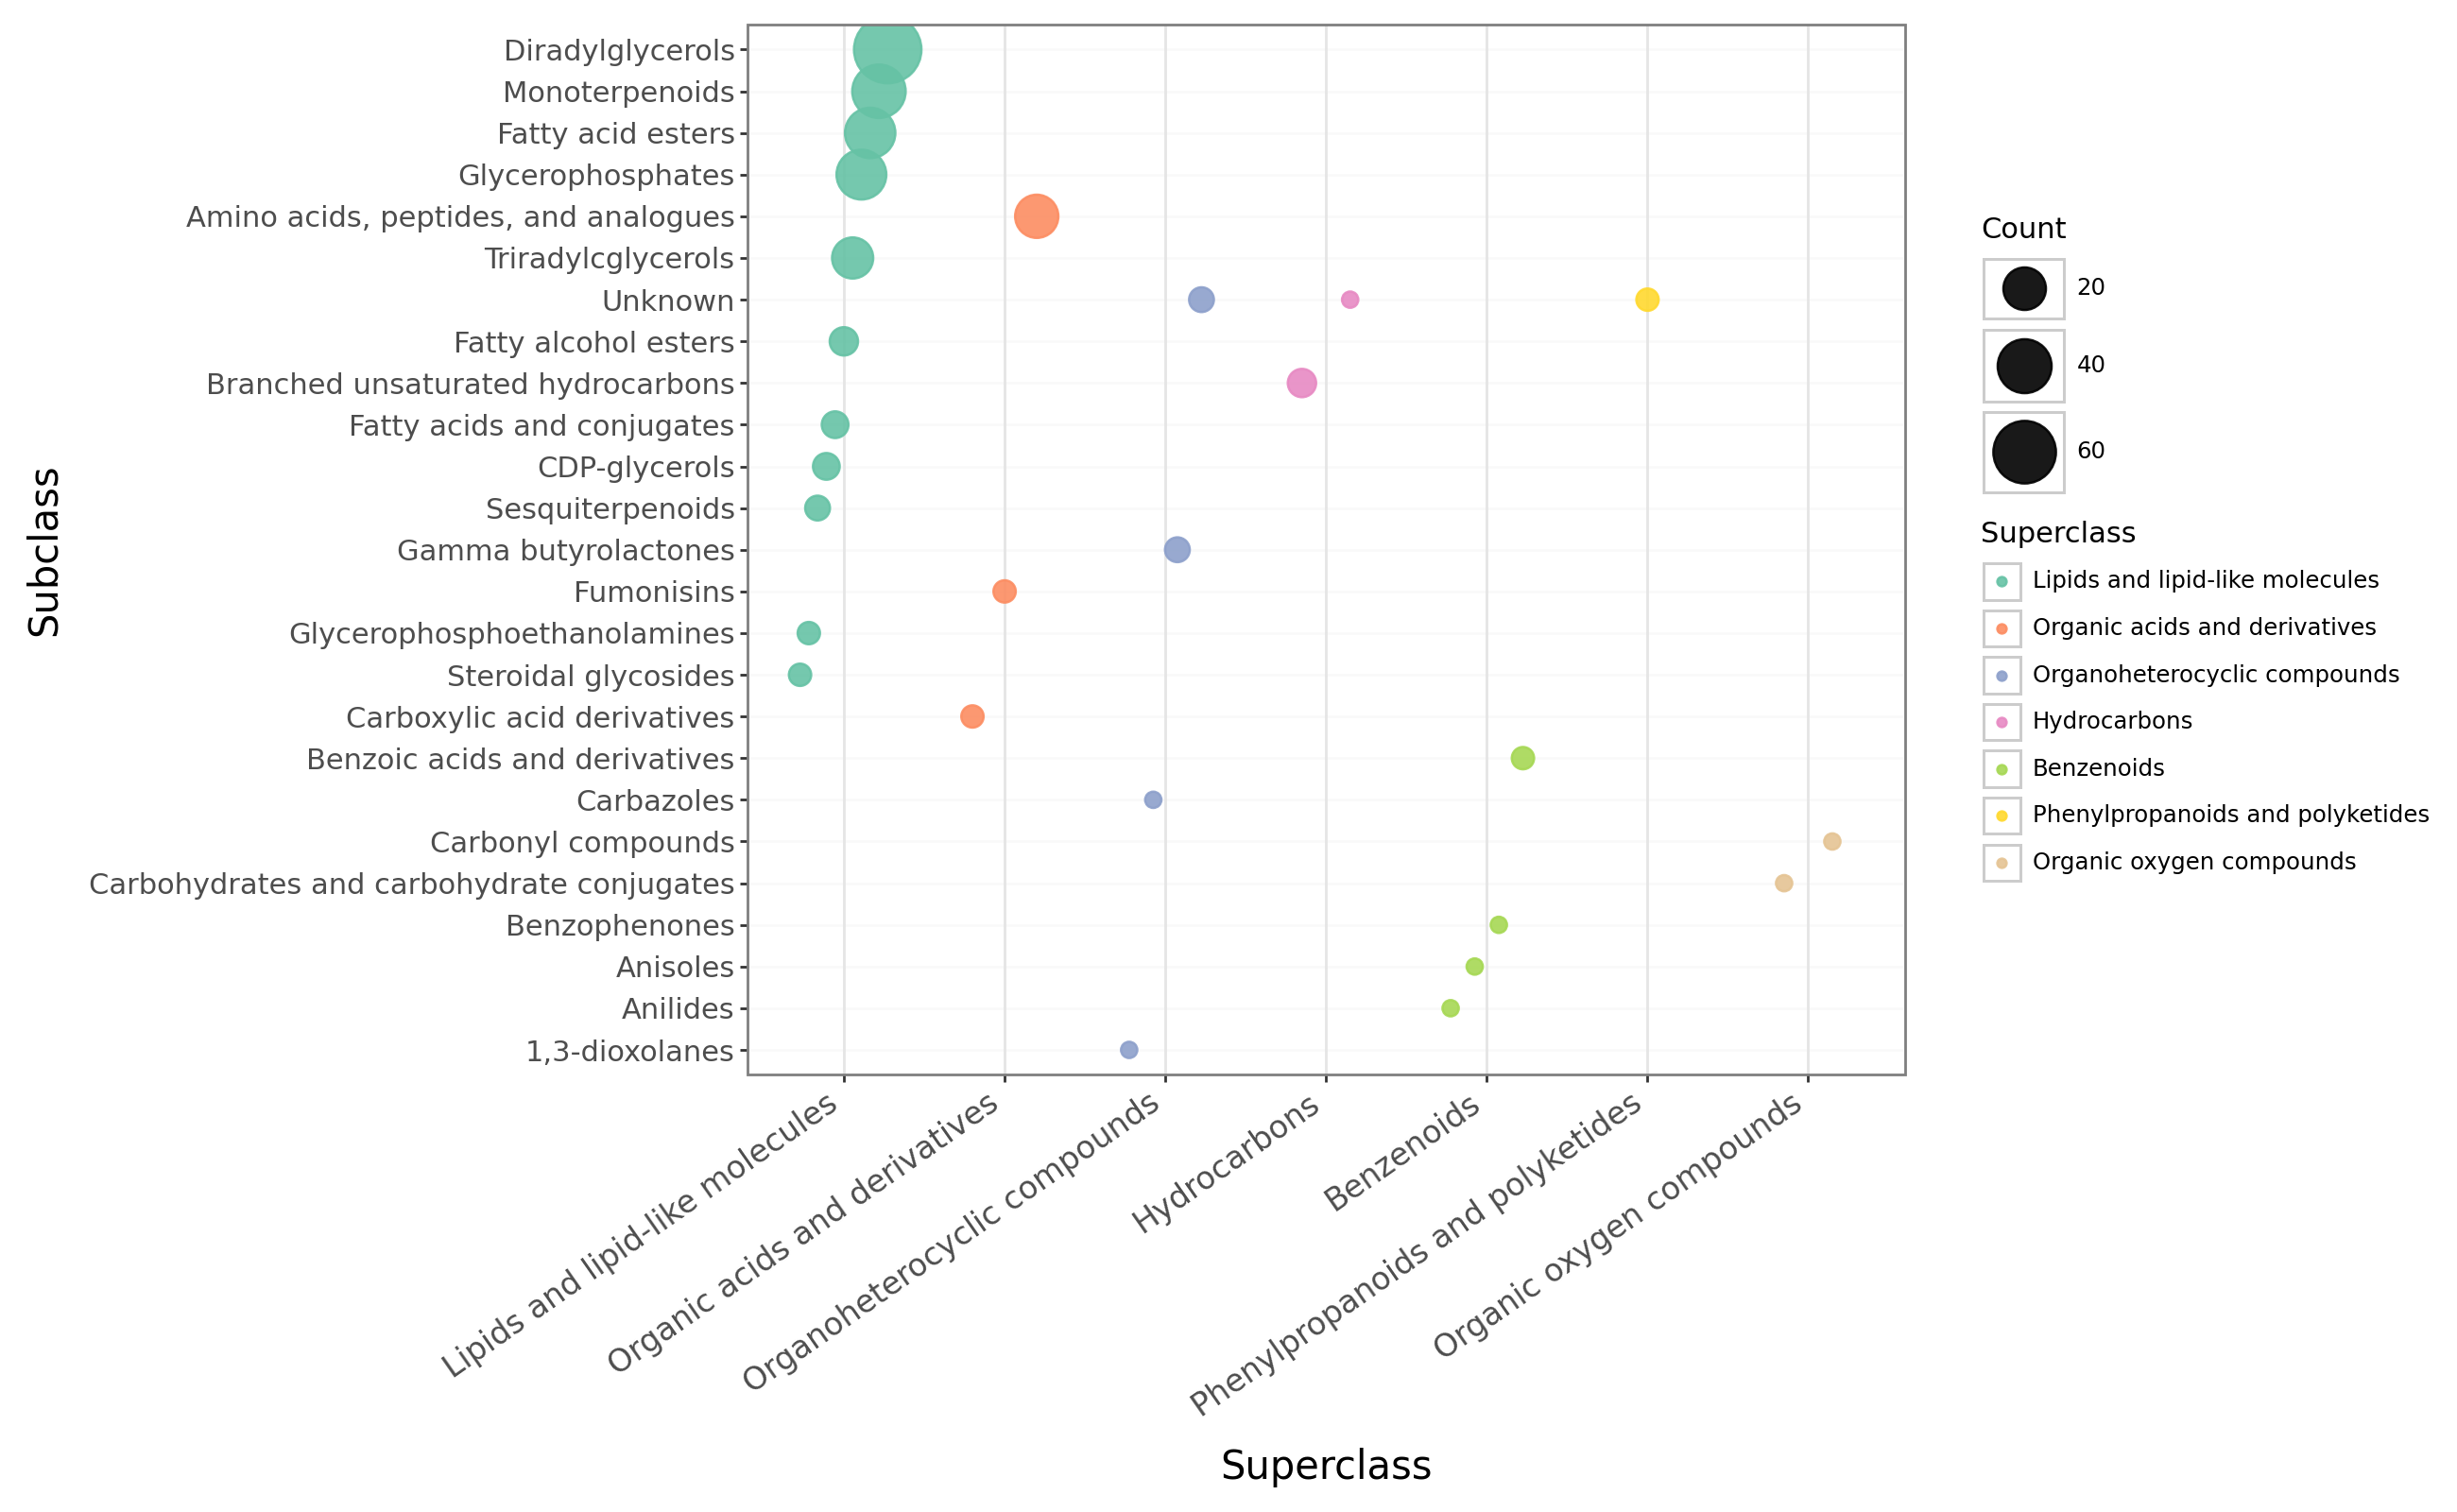

In [ ]:
#imports
!pip -q install plotnine
import pandas as pd
from plotnine import (ggplot, aes, geom_point, theme_bw, theme, element_text, labs, scale_size_continuous, scale_color_brewer, position_dodge)

# df_top already filtered to top7 superclasses
df_top["subclass"] = df_top["subclass"].fillna("Unknown")
df_top["superclass"] = df_top["superclass"].fillna("Unknown")

# count metabolites per (superclass, subclass)
d = (df_top.groupby(["superclass","subclass"]).size().reset_index(name="count"))
top_sub = d.groupby("subclass")["count"].sum().sort_values(ascending=False).head(25).index
d = d[d["subclass"].isin(top_sub)].copy()

# Order x by total counts
x_order = (df_top["superclass"].value_counts().loc[top7].index.tolist())
d["superclass"] = pd.Categorical(d["superclass"], categories=x_order, ordered=True)

# Order y by overall subclass frequency (largest at top)
y_order = (d.groupby("subclass")["count"].sum().sort_values(ascending=True).index.tolist())
d["subclass"] = pd.Categorical(d["subclass"], categories=y_order, ordered=True)

p = (
  ggplot(d, aes(x="superclass", y="subclass", size="count", color="superclass"))
  # dodge adds horizontal spacing between dots in same row
  + geom_point(alpha=0.9, position=position_dodge(width=0.6))
  # better size scaling
  + scale_size_continuous(range=(3,14))
  # nice muted palette (paper-like)
  + scale_color_brewer(type="qual", palette="Set2")
  + theme_bw()
  + theme(
      figure_size=(13,8),
      axis_text_x=element_text(rotation=35, ha="right", size=12),
      axis_text_y=element_text(size=11),
      axis_title_x=element_text(size=15),
      axis_title_y=element_text(size=15),
      # more vertical breathing room
      panel_grid_major_y=element_text(alpha=0.2),
    )
  + labs(x="Superclass", y="Subclass", size="Count", color="Superclass")
)

p